# Computational Social Science Project #3 

**Enter your Name:** Alan Mozaffari

*Semester:* Fall 2025

## 1. Introduction

### Load data 

In [74]:
#
# load libraries
# -----------
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# There are a few warnings that will appear that will not affect your analysis. Run this code to ignore. 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Make sure to import other libraries that will be necessary for training models!

In [2]:
#
# read in "Inspections Data 2011-2013" csv data
# -----------
chicago_inspections_2011_to_2013 = pd.read_csv("data/Chicago Inspections 2011-2013.csv", 
                                              low_memory=False)

#
# read in  "Inspections Data 2014_updated" csv data
# -----------
chicago_inspections_2014 = pd.read_csv("data/Chicago Inspections 2014_updated.csv",  # be sure to use the "updated" data here
                                      low_memory=False)

In [64]:
# look at the inspections data
chicago_inspections_2011_to_2013

,,Facility_Type,Risk,Inspection_Type,Results,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_DESCRIPTION,APPLICATION_TYPE,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,Grocery Store,Risk 3 (Low),Canvass,Pass,Other,0,0,2,0,0,0,0,2.000000,1,44-33,19.0,Retail Food Establishment,RENEW,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0
507211,PANERA BREAD,Restaurant,Risk 1 (High),Canvass,Pass,Restaurant,0,0,3,0,0,0,0,2.000000,1,50-23,24.0,Retail Food Establishment,RENEW,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0
507212,LITTLE QUIAPO RESTAURANT,Restaurant,Risk 1 (High),Canvass,Fail,Restaurant,0,2,6,0,0,0,0,2.000000,1,50-25,17.0,Retail Food Establishment,RENEW,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0
507216,SERGIO'S TAQUERIA PIZZA INC.,Restaurant,Risk 1 (High),Canvass,Pass,Restaurant,0,0,6,0,0,0,0,2.000000,1,39-48,17.0,Retail Food Establishment,RENEW,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0
507219,TARGET STORE # T-2079,Restaurant,Risk 2 (Medium),Canvass,Fail,Restaurant,0,2,6,0,0,0,0,2.000000,1,40-18,24.0,Retail Food Establishment,RENEW,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1393258,CIAO BELLA CAFE,Restaurant,Risk 1 (High),Canvass,Pass,Restaurant,0,0,6,1,0,2,6,0.452055,0,49-36,24.0,Retail Food Establishment,ISSUE,0.726027,0,0,0,0,0,0,0,0,0,0,0,0,0.002300,25.370000,7.963333,0.776667,10.537839,1.376266,21.726951,0
1395218,Christian Fields Style Bar,Restaurant,Risk 2 (Medium),Canvass,Pass,Restaurant,0,0,4,0,0,1,4,1.200000,0,20-18,3.0,Retail Food Establishment,RENEW,4.120548,0,0,0,0,0,1,0,0,0,0,0,0,0.000100,34.586667,9.820000,0.676667,56.680038,19.736283,32.355622,0
1395224,W CHICAGO - LAKESHORE,Restaurant,Risk 1 (High),Canvass,Pass w/ Conditions,Restaurant,3,3,5,0,0,0,0,2.000000,1,42-63,18.0,Retail Food Establishment,ISSUE,0.879452,0,0,0,0,0,0,0,0,0,0,0,0,0.000100,34.586667,9.820000,0.676667,10.937753,0.000002,19.213021,1


In [4]:
# list column names
chicago_inspections_2011_to_2013.columns

Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'Inspection_Type', 'Results', 'Latitude', 'Longitude', 'Location',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pass_flag', 'fail_flag', 'pastFail', 'pastCritical', 'pastSerious',
       'pastMinor', 'timeSinceLast', 'firstRecord', 'ID', 'LICENSE_ID',
       'ACCOUNT_NUMBER', 'LEGAL_NAME', 'DOING_BUSINESS_AS_NAME', 'ADDRESS',
       'CITY', 'STATE', 'ZIP_CODE', 'WARD', 'PRECINCT', 'WARD_PRECINCT',
       'POLICE_DISTRICT', 'LICENSE_CODE', 'LICENSE_DESCRIPTION',
       'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY', 'LICENSE_NUMBER',
       'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE',
       'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE',
       'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods',

In [5]:
# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2011_to_2013.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE',
                                                 'pass_flag',
                                                 'fail_flag'],
                                     inplace = True)

# set index
chicago_inspections_2011_to_2013.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

In [6]:
# convert the inspection date to a datetime format
chicago_inspections_2011_to_2013['Inspection_Date'] = pd.to_datetime(chicago_inspections_2011_to_2013['Inspection_Date'])  

### Visualization

Let's visualize what inspections look like over time.

In [7]:
# visualize inspections over time
# -----------
chicago_inspections_2011_to_2013['Inspection_MonthYear'] = chicago_inspections_2011_to_2013['Inspection_Date'].dt.to_period('M')
counts_by_day = chicago_inspections_2011_to_2013.groupby('Inspection_MonthYear').count().rename(columns = {'Facility_Type': 'Count'})['Count'].reset_index()
counts_by_day.set_index(["Inspection_MonthYear"], inplace = True)
counts_by_day.plot(title = "Inspections by Month and Year") 

<Axes: title={'center': 'Inspections by Month and Year'}, xlabel='Inspection_MonthYear'>

Let's visualize what the distribution of results looks like.

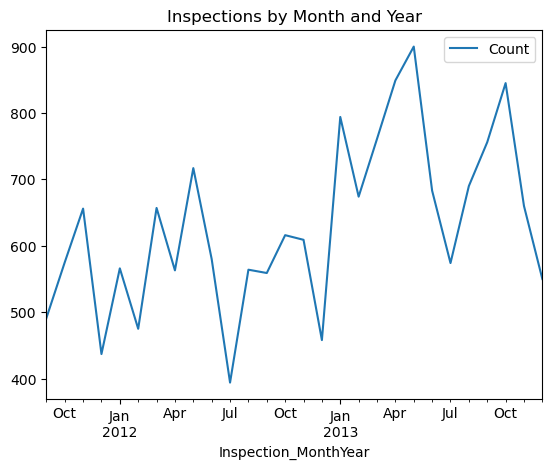

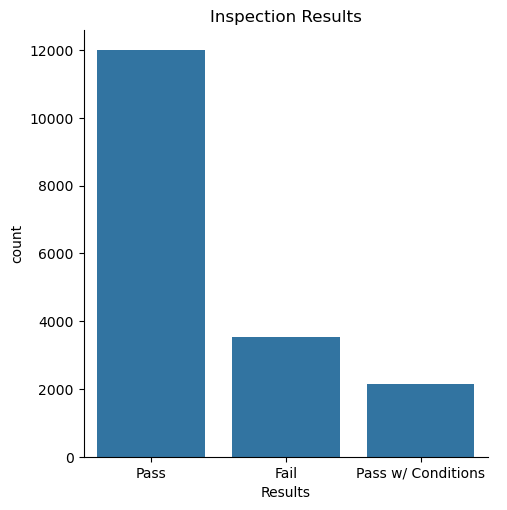

In [8]:
# view inspection results
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
           x = "Results",
           kind = "count")

plt.title("Inspection Results")
plt.show()

What if we separate results by facility type?

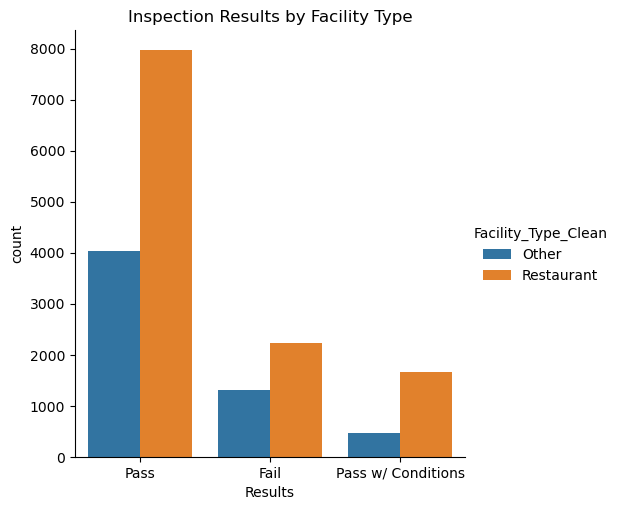

In [9]:
# view inspection results by facility type (restaurant or not)
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
            x = "Results",
            kind = "count",
            hue = 'Facility_Type_Clean')

plt.title("Inspection Results by Facility Type")
plt.show();

## 2. Data Preprocessing and Cleaning

In [10]:
# drop datetime info
# -----------
chicago_inspections_2011_to_2013 = chicago_inspections_2011_to_2013.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate',
                                                                                   'Inspection_MonthYear'],
                                                                                  axis = 1)

In [11]:
# process target 
# -----------
y = chicago_inspections_2011_to_2013['Results']

# decide if you want to binarize the outcome variable 
# -----------
# comment out the following lines of code if you don't want to binarize the target variable
y = y.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y = lb_style.fit_transform(y)

# recode 0s and 1s so 1s are "Fail"
y = np.where(y == 1, 0 ,1)


# process features
# -----------

# create feature dataset
X = chicago_inspections_2011_to_2013.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])


# get dummies
X = pd.get_dummies(X)

In [12]:
# view feature datset
X.head()

,,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,POLICE_DISTRICT,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Risk_Risk 1 (High),Risk_Risk 2 (Medium),Risk_Risk 3 (Low),Inspection_Type_Canvass,Facility_Type_Clean_Other,Facility_Type_Clean_Restaurant,APPLICATION_TYPE_C_EXPA,APPLICATION_TYPE_C_LOC,APPLICATION_TYPE_ISSUE,APPLICATION_TYPE_RENEW
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,0,0,2,0,0,0,0,2.0,1,19.0,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0,False,False,True,True,True,False,False,False,False,True
507211,PANERA BREAD,0,0,3,0,0,0,0,2.0,1,24.0,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0,True,False,False,True,False,True,False,False,False,True
507212,LITTLE QUIAPO RESTAURANT,0,2,6,0,0,0,0,2.0,1,17.0,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0,True,False,False,True,False,True,False,False,False,True
507216,SERGIO'S TAQUERIA PIZZA INC.,0,0,6,0,0,0,0,2.0,1,17.0,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0,True,False,False,True,False,True,False,False,False,True
507219,TARGET STORE # T-2079,0,2,6,0,0,0,0,2.0,1,24.0,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,0,False,True,False,True,False,True,False,False,False,True


In [13]:
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(0): np.int64(12224), np.int64(1): np.int64(3087)}


## 3. Fit Models

Now choose 3 different machine learning techniques and apply them below. Choose from one of the algorithms we have used in lab (e.g., logistic regression, random forests, `AdaBoost()`, `xgboost()`, `VotingClassifer()`, or `BART`). 

Detail the basic logic and assumptions underlying each model, its pros/cons, and why it is a plausible choice for this problem. Also, be sure to do the following:

1. Import the appropriate library from sklearn
2. Set up a hyperparameter grid (check out our previous labs to see how to do this)
3. Find the best hyperparameters, and then fit your model (using either train/validation splits or cross-validation)

### Answer: Model Descriptions

I chose to do 5-fold cross validation for each model instead of test-validation splitting (and saving test set for 2014 data). 

#### Logistic Regression

**Basic logic and assumptions**: Logistic regressions models the probability of a binary outcome as a logistic function of different input predictors. It assumes there is a linear relationship between the log-odds of the outcomes and predictors

**Pros**: Logistic regression models are simple to fit and follow similar modeling strategies to OLS regression. Their outcomes can be converted into probabilities, which are easy to interpret. They also can be done successfully on small datasets and are fast to train.

**Cons**: Because the assumption is a linear relationship between log-odds of the outcomes and predictors, non-linear relationships cannot be estimated without any adjustments. Complex relationships (like many interaction terms) and outliers may also challenge model performance and estimation. Furthermore, log-odds and odds-ratios may be difficult to interpret for the general public (even though they can be converted into probabilities).

**Plausible choice for this problem**: Logistic Regression is a classification method that allows predications on binary outcomes. Because we are trying to predict whether a business passed or failed an inspection, this method situates itself well for such a binary outcome. 


#### Random Forests

**Basic logic and assumptions**: A decision tree takes an outcome and a set of predictors and predicts the outcome by recursively splitting the dataset based on the predictors. At each split, the algorithm chooses the best cut that maximally reduces impurity (like variance for regression, or Gini index or entropy for classification). Splits are made sequentially, one at a time, until stopping criteria are met (i.e., maximum depth, minimum samples per leaf). Thus, a random forest builds many decision trees in parallel (as an ensemble method) on bootstrapped samples of the data and uses random subsets of predictors at each split. Predictions are then averaged (regression) or voted on (classification) across trees, which reduces variance and improves generalization compared to a single tree. Observations are assumed to be independent, and that there are a number of features that plausibility predict the outcome. 

**Pros**: Unlike logistic regression, random forests can handle complex patterns (like non-linearity) and outliers better, especially in large and complex data sets. It also can allow for relatively limited subject-matter expertise and variable selection, as the model can figure out which variables have more predicative power than others in the absence of picking variables based on theory. 

**Cons**: As an ensemble method number of different trees fit and parameters tuned, random forests can require lots of computational power and time. Their interpretability might also be hard to generalize to the public, although we have metrics like variable importance to help.

**Plausible choice for this problem**: Because of the large number of features and variety of different businesses and their unique elements, random forests are helpful here to find novel patterns between the features. This may allow to find non-linear patterns that other classification methods may not be able to do. Because random forests can handle lots of different predictors, we do not have to fully rely on subject-matter or domain expertise to decide on model configurations, and include all features to let the model decide. 


#### XGBoost

**Basic logic and assumptions**: Boosting methods also use decision trees, but estimate them sequentially. They start with a strong classifier, then iterates on subsequent week learners using the remaining prior prediction error. XGBoosting specifically uses Gradient Descent to minimize a loss function and improve fit -- it uses a mixture of both the loss function and regulation parameters. 

**Pros**: Its sequential tree estimation allows for the prevention of overfitting. It can work on a number of different kinds of outcomes (binary, continuous, and rank) and complex datasets, with or without missingness. While it is computationally intensive, it can also take advantage of parallelization for more efficient processing on a computer environment. 

**Cons**: Regardless of computer environment, it is still computationally intensive. There are many hyperparameters to pick from, and deciding how many to tune and to what extent given the power of the computer environment is a tradeoff. It is similarly difficult to explain results compared to a method like logistic regression.

**Plausible choice for this problem**: Similar to random forest, as an ensemble method handling a number of different features and investigating potential non-linear relationships, XGBoost is useful in this classification question. It similarly does not fully require domain expertise as the model is able to take in a large number of variables and identify feature importance.


### Model 1: Logistic Regression

In [114]:
#see what parameters are in the model
#LogisticRegression().get_params()

In [75]:
#create hyperparameter tuning grid search
logit_reg = LogisticRegression(max_iter = 1000, solver = 'liblinear')

param_grid_logit = {
              'penalty': ['l1', 'l2'],
              'C': np.arange(.1, 10, .1),
              'fit_intercept': [True, False]}
                 

log_grid_reg = RandomizedSearchCV(estimator  = logit_reg,      
                            param_distributions = param_grid_logit,   
                            cv=5)   

log_grid_reg.fit(X, y.ravel())

best_logit_model = log_grid_reg.best_estimator_

###  Model 2: Random Forest

In [167]:
#RandomForestClassifier().get_params()

In [15]:
rf_classifier = RandomForestClassifier(criterion='gini',
                                       min_weight_fraction_leaf=0.0,
                                       min_impurity_decrease=1e-07,
                                       random_state = 10)     

param_grid_rf ={
    'n_estimators': np.arange(100, 310, 10),
    'max_depth': [None, 5, 10, 20, 40],
    'min_samples_split': [2, 5, 10,15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
    }

rf_grid_reg = RandomizedSearchCV(estimator = rf_classifier,      
                                 param_distributions = param_grid_rf,
                                 cv=5,
                                n_jobs = 5)   
rf_grid_reg.fit(X, y.ravel())

best_rf_model = rf_grid_reg.best_estimator_

### Model 3: XGBoost

In [21]:
#xgb.XGBClassifier().get_params()

In [16]:
xgb_classifier = xgb.XGBClassifier(random_state=10)

param_grid_boost = {
    'n_estimators': np.arange(100, 410, 10),
    'max_depth': np.arange(2, 10, 1),
    'learning_rate': np.arange(.01, .2, .01),
    'subsample': np.arange(.1, 1, .1),
    'colsample_bytree': np.arange(.1, 1, .1),
    'gamma': np.arange(.1, 1, .1),
    'reg_alpha': np.arange(0, .1, .01),
    'reg_lambda': [1, 1.5, 2]
}


boost_grid_reg = RandomizedSearchCV(estimator = xgb_classifier,      
                                 param_distributions = param_grid_boost,
                                 cv=5,
                                n_jobs = 5)   

boost_grid_reg.fit(X,y.ravel())

best_boost_model = boost_grid_reg.best_estimator_

### Validation Metrics

Be sure to explain which of these metrics you would want to prioritize when conducting predictive auditing in this context and why.

**Hint**: Try writing a for loop to use [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to check for accuracy, precision, recall and f1 across all of your models.

In [17]:
models = {
    "Logistic Regression": best_logit_model,
    "Random Forest": best_rf_model,
    "XGBoost": best_boost_model,
}

# use scoring functions from sklearn.metrics
scoring_metrics = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score)
}

# loop over the three models and metrics
for model_name, model in models.items():
    print(f"--- {model_name} ---")
    for metric_name, scorer in scoring_metrics.items():
        scores = cross_val_score(model, 
                                 X, 
                                 y.ravel(), 
                                 cv=5, 
                                 scoring=scorer)
        print(f"{metric_name.capitalize()}: {scores.mean():.3f} ± {scores.std():.3f}")
    print("\n")

--- Logistic Regression ---
Accuracy: 0.922 ± 0.004
Precision: 0.785 ± 0.027
Recall: 0.853 ± 0.043
F1: 0.816 ± 0.010


--- Random Forest ---
Accuracy: 0.926 ± 0.005
Precision: 0.769 ± 0.017
Recall: 0.906 ± 0.026
F1: 0.831 ± 0.012


--- XGBoost ---
Accuracy: 0.924 ± 0.005
Precision: 0.776 ± 0.020
Recall: 0.876 ± 0.026
F1: 0.822 ± 0.010




### Answer: Validation Metric Priority

Across the logistic regression, random forest, and XGBoost models, they all performed very similarly on Accuracy, Precision and F1 scores. However, there seems to be the most (albeit still quite small) variation between the Recall scores, for the logistic regression vs. the random forest/XGBoost models -- these scores also have the highest standard deviations. I would be interested in focusing on the model with the highest recall score not just because this is where models differ the most from each other, but more importantly because recall (or sensitivity) captures the model’s ability to correctly identify true positives. In this context, a “positive” case is a business that fails its safety inspection. Prioritizing recall means we are working to minimize false negatives, where business that actually fail inspections are predicted to pass. 

This priority has strong implications for population health. If a business that should fail inspection is incorrectly predicted to pass, the business may continue operating under unsafe and unhealthy conditions without being audited, posing health risks to its surrounding community. Therefore, it's important to ensure that as many failing businesses as possible are correctly flagged to fail, even if it risks increasing the number of passing business to be incorrectly predicted to fail. The cost of a false negative in this situation is perhaps thus far greater than that of a false positive. Because of this, the random forest model will be what I look at next given its highest recall score. 

## 4. Policy Simulation

### Interpretable Machine Learning

Use tools like coefficient plots or feature importance plots to investigate your models. Which features contribute to your predictions? Are there any additional features you wish you could incorporate that you don't have available in this analysis?

**Hint**: Use tools like feature importance plots and coefficient plots.

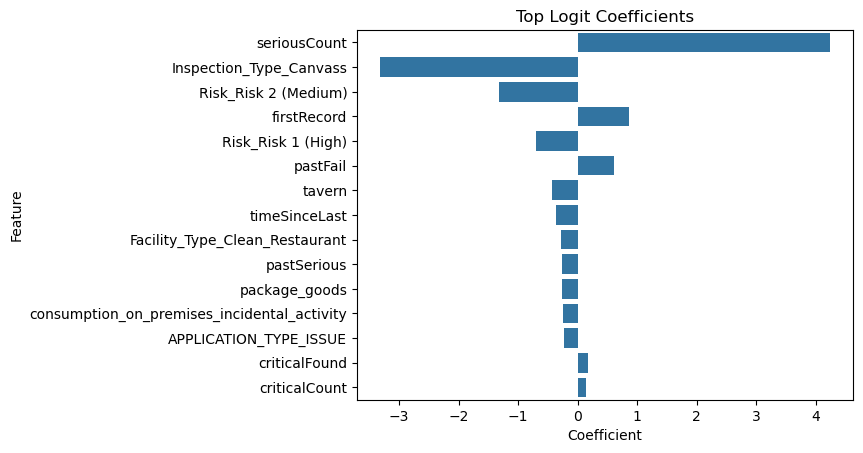

In [18]:
#Logistic Regression

logit_data = pd.concat([pd.DataFrame(X.columns),
                        pd.DataFrame(np.transpose(best_logit_model.coef_))],
                       axis = 1)

logit_data.columns = ['Feature', 'Coefficient']
logit_data['abs_coef'] = abs(logit_data['Coefficient'])

# plot 
sns.barplot(x="Coefficient", 
            y="Feature", 
            data=logit_data.nlargest(15, 'abs_coef')).set_title("Top Logit Coefficients")
plt.show()

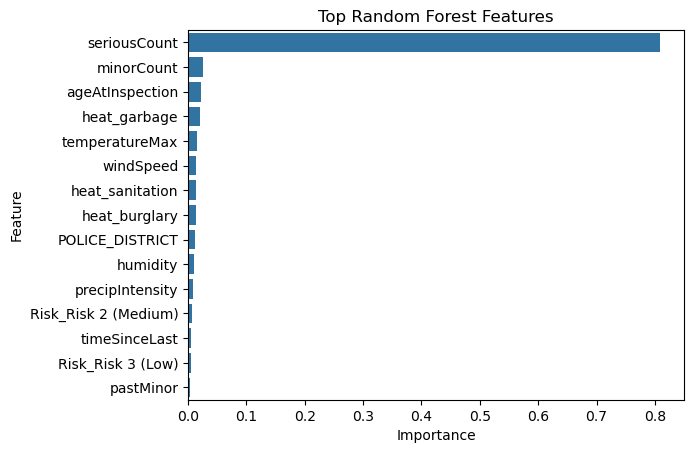

In [21]:
# Random Forest
feat_importances = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(best_rf_model.feature_importances_))], axis = 1)
feat_importances.columns = ["Feature", "Importance"]

# plot 
sns.barplot(x = "Importance", 
            y = "Feature", 
            data = feat_importances.nlargest(15, 'Importance')).set_title("Top Random Forest Features")
plt.show()

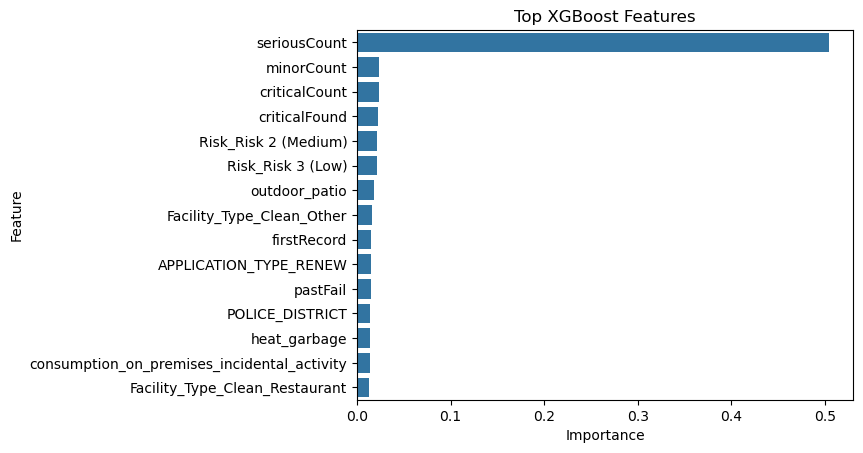

In [20]:
# XGBoost
feat_importances = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(best_boost_model.feature_importances_))], axis = 1)
feat_importances.columns = ["Feature", "Importance"]

# plot 
sns.barplot(x = "Importance", 
            y = "Feature", 
            data = feat_importances.nlargest(15, 'Importance')).set_title("Top XGBoost Features")
plt.show()

### Answer: Interpretable Machine Learning:
Across all three models, `seriousCount` was the most important predictive feature. I can imagine that this is the count of number of violations or adverse indicators that would be considered as serious to count against a passing grade, which makes sense given how related that would be to the outcome. For the random forest and XGBoost models, `minorCount` is the second most predictive feature, with `criticalCount` and `criticalFound` being the third and fourth most predictive features for the XGBoost model. Compared with `seriousCount`, `minorCount` and `criticalCount` seem to fall one less and more degree in severity. Thus, the number of violations or warnings that fall in this middle range seem to be predictive compared to all other degrees of violations. It might be that the `seriousCount` criteria has a much wider range, thus there are more likely violations, but also might suggest that some critical factors may not be as "critical" in determining whether a business passes or fails inspection.

Both the logistic model and the XGBoost model have `Risk_Risk` features of various degrees as well as `firstRecord` and `pastFail` as somewhat predictive features, while the random forest has repeated `heat_` variables (like `_garbage`, `_burglary`, and `_sanitation`) as somewhat predicitve features. 

While we did remove location features, I actually would be curious to see the geographic details of businesses as well as the racial composition of each block. Especially with how racialized geography is within Chicago with its history of structural racism, might there be more businesses that are failing in some neighborhoods that have higher populations of racial minorities over others that do not? Would this then lead to investigating if businesses matched on very similar characteristics are receiving the same distribution of pass/failing rates, or are some communities over-surveilled and over-scrutinized over others, potentially failing at higher rates despite similar patterns of predictive features at the business level? 

Furthermore, while we later do arrange observations by predicted risk and can see each business's predicted risk, it would also be interesting to create covariates of the kinds of owners of each business (aside from just looking at what their names say). I.e., is the business owned by a large corporation or chain? Are they mom-and-pop, independent business? I can imagine that large corporations perhaps have large capacity for compliance and oversight (and lawyers) in ways that smaller business do not. And if there is an unequal distribution of what kinds of businesses are failing, it could suggest some structural, city-level support for small businesses might be helpful to ensure that they are not at high risk of failing before they are inspected.

### Prioritize Audits

**Hint**: Look up the [`.predict()`](https://www.kite.com/python/docs/sklearn.linear_model.SGDRegressor.predict), [`.predict_proba()`](https://www.kite.com/python/docs/sklearn.linear_model.LogisticRegression.predict_proba), and [`.sample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) methods. Then: 
1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities. 
2. Order your audits by their probability of detecting a "Fail" score
3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

In [76]:
#
# 1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities.
# -----------
#Using random forest
preds_df = pd.DataFrame({
    "Predicted Failed Audit": best_rf_model.predict(X),
    "Predicted Probability of Failed Audit": best_rf_model.predict_proba(X)[:, 1],
    "Store ID": X.index,
    "True Pass/Fail": np.ravel(y)
})

preds_df.head()

,Predicted Failed Audit,Predicted Probability of Failed Audit,Store ID,True Pass/Fail
0,0,0.000000,"(269961, SEVEN STAR)",0
1,0,0.000000,"(507211, PANERA BREAD)",0
2,1,0.928335,"(507212, LITTLE QUIAPO RESTAURANT)",1
3,0,0.000000,"(507216, SERGIO'S TAQUERIA PIZZA INC.)",0
4,1,0.807893,"(507219, TARGET STORE # T-2079)",1


In [27]:
#
# 2. Order your audits by their probability of detecting a "Fail" score
# -----------

preds_df_sorted = preds_df.sort_values(by="Predicted Probability of Failed Audit", ascending=False).head(1000)
preds_df_sorted


,Predicted Failed Audit,Predicted Probability of Failed Audit,Store ID,True Pass/Fail
13758,1,0.999102,"(1353212, LITTLE CAESAR ENTERPRISES, INC.)",1
8449,1,0.998868,"(1202791, TASTY BEEF & SUB,INC.)",1
10540,1,0.998847,"(1285733, WILEY'S CHICKEN & RIBS)",1
6268,1,0.998799,"(1150845, SUFWAN LAUNDRIES)",1
3188,1,0.998799,"(920229, BURGER KING #1250)",1
...,...,...,...,...
3610,1,0.897420,"(1092373, Jitlada Thai House Restaurant)",1
6552,1,0.897012,"(1151524, M & D GROCERY STORE)",1
7671,1,0.896733,"(1188534, THE FAMOUS TACO BURRITO KING)",1
13839,1,0.896723,"(1353488, SAFARI RESTAURANT)",1


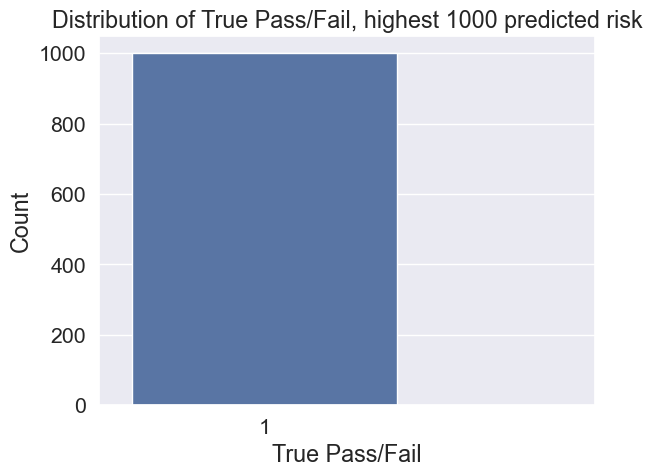

In [82]:
#
# 3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
# -----------

sns.countplot(x="True Pass/Fail", data=preds_df_sorted)
plt.title("Distribution of True Pass/Fail, highest 1000 predicted risk")
plt.xlabel("True Pass/Fail")
plt.ylabel("Count")
plt.xticks([0,1])
plt.show()


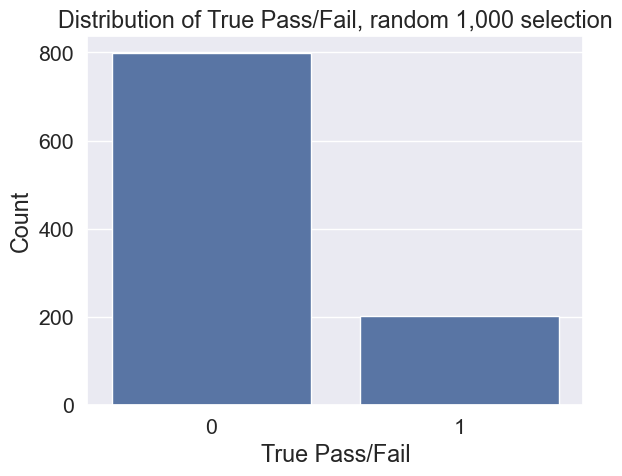

In [81]:
#
# 4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random
# -----------

audit_at_random = preds_df.sample(n=1000,random_state=273,replace=False) #random sample of 1,000 from step 1 in this part

sns.countplot(x="True Pass/Fail", data=audit_at_random)
plt.title("Distribution of True Pass/Fail, random 1,000 selection")
plt.xlabel("True Pass/Fail")
plt.ylabel("Count")
plt.xticks([0,1])
plt.show()



### Answer: Audit Priority Reflection

The random forest model does a good job at predicting correctly whether a business would fail or not, as evident by its high recall score. When we ordered the businesses and viewed their audits by predicted probability of failing, our highest 1,000 predicted riskiest businesses resulted in 100% of them actually failing inspection. But when we randomly select 1,000 businesses to audit, we are not accounting for any predicted risk scores and are just getting a true random sample of the data. Thus, 80% of the randomly selected businesses passed, while only 20% failed. If we are inclined to ensure we are spending our resources towards 1,000 businesses and dedicate such efforts to failing businesses so that they do not continue operating under unhealthy or unsafe conditions, then arranging by predicted risk is the appropriate step to go such that resources can be more targeted for better population health outcomes.

### Predict on 2014 inspection data

Use your favorite model to make predictions based on the features using the "Chicago Inspection 2014_updated.csv" file. Treat this as you would a test dataset. This means you will have to format the features (including removing some features and getting dummies) and the label (binarize and recode) in the same way you did the training data. (Remember the "Results" column is your label). You will then compare your predictions with the actual.

In [137]:
chicago_inspections_2014.head()

,,Inspection_Date,Facility_Type,Risk,Inspection_Type,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_DESCRIPTION,APPLICATION_TYPE,minDate,maxDate,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Results
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
920444,GALLISTEL LANGUAGE ACADEMY,2014-01-15,School,Risk 1 (High),Canvass,Other,0,1,5,0,0,0,2,0.964384,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,41.67,13.533333,0.726667,2.149376,7.705332,9.535848,0,Fail
920445,SUBWAY,2014-02-03,Restaurant,Risk 1 (High),Canvass,Restaurant,2,0,0,0,0,0,0,0.794521,0,10-38,4.0,Retail Food Establishment,ISSUE,2012-08-29,2018-09-15,1.432877,0,0,0,0,0,0,0,0,0,0,0,0,0.002300,28.16,6.020000,0.746667,12.034833,7.194320,1.219222,1,Pass w/ Conditions
920446,SHARKS FISH & CHICKEN,2014-02-03,Restaurant,Risk 2 (Medium),Canvass,Restaurant,0,0,6,0,0,0,2,0.660274,0,7-49,4.0,Retail Food Establishment,RENEW,2004-03-02,2018-07-15,9.931507,0,0,0,0,0,0,0,0,0,0,0,0,0.002300,28.16,6.020000,0.746667,26.292725,27.837325,12.401466,0,Pass
920448,P K PETRO INC.,2014-03-07,Grocery Store,Risk 3 (Low),Canvass,Other,0,1,7,0,0,0,0,2.000000,1,5-21,3.0,Retail Food Establishment,RENEW,2003-03-05,2018-12-15,11.013699,0,1,0,0,0,0,0,0,0,1,0,0,0.000433,25.30,7.653333,0.636667,49.468944,11.282325,66.467028,0,Fail
920449,"Z T DOLLAR EXCHANGE,INC",2014-03-07,Grocery Store,Risk 3 (Low),Canvass,Other,1,2,5,0,0,0,0,2.000000,1,7-40,3.0,Retail Food Establishment,ISSUE,2012-10-09,2018-12-15,1.408219,0,1,0,0,0,1,0,0,0,0,0,0,0.000433,25.30,7.653333,0.636667,69.939833,26.695701,76.827119,1,Fail


In [22]:
# data processing
# -----------
chicago_inspections_2014.head()

# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2014.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE'],
                                     inplace = True)

# set index
chicago_inspections_2014.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

# drop datetime info
# -----------
chicago_inspections_2014 = chicago_inspections_2014.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate'],
                                                                              
                                                                                  axis = 1)

# process target 
# -----------
y_test2014 = chicago_inspections_2014['Results']

# decide if you want to binarize the outcome variable 
# -----------
# comment out the following lines of code if you don't want to binarize the target variable
y_test2014 = y_test2014.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y_test2014 = lb_style.fit_transform(y_test2014)

# recode 0s and 1s so 1s are "Fail"
y_test2014 = np.where(y_test2014 == 1, 0 ,1)


# process features
# -----------

# create feature dataset
X_test2014 = chicago_inspections_2014.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])


# get dummies
X_test2014 = pd.get_dummies(X_test2014)


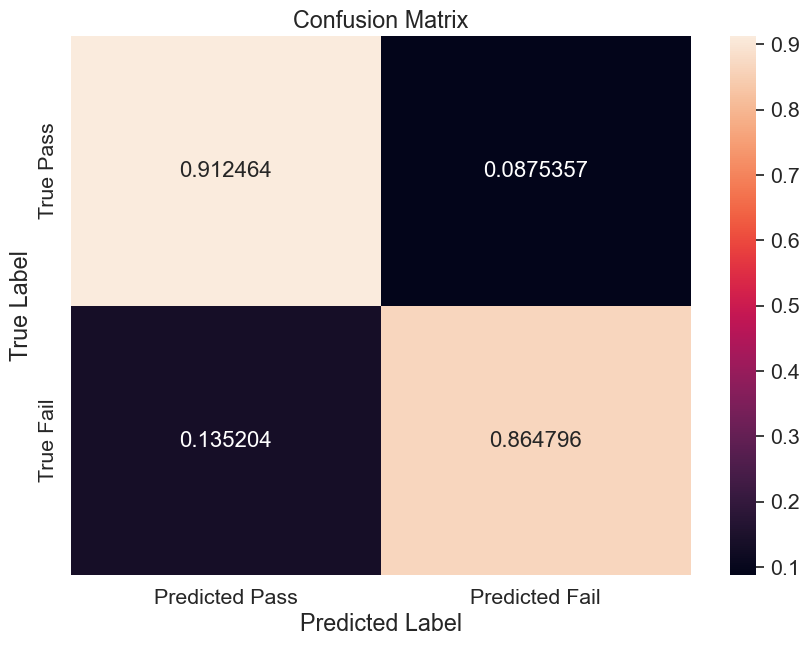

In [73]:
# predict and compare 
# -----------

y_test2014_preds=best_rf_model.predict(X_test2014)

cf_matrix = confusion_matrix(y_true = y_test2014, 
                             y_pred = y_test2014_preds, 
                             normalize = "true")

# convert to a dataframe
df_cm = pd.DataFrame(cf_matrix, range(2), range(2))

# set figure specifications
df_cm = df_cm.rename(index=str, columns={0: "Predicted Pass", 1: "Predicted Fail"})
df_cm.index = ["True Pass", "True Fail"]
plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)
sns.heatmap(df_cm, 
           annot=True,
           annot_kws={"size": 16},
           fmt='g')

#plot
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [55]:
scoring = ["accuracy", "precision", "recall", "f1"]

print("--- Random Forest Performance, 2013 ---")

for metric in scoring:
    scores = cross_val_score(best_rf_model, 
                             X, 
                             y.ravel(), 
                             cv=5, 
                             scoring=metric)
    print(f"{metric.capitalize()}: {scores.mean():.3f} ± {scores.std():.3f}")

--- Random Forest Performance, 2013 ---
Accuracy: 0.926 ± 0.005
Precision: 0.769 ± 0.017
Recall: 0.906 ± 0.026
F1: 0.831 ± 0.012


In [63]:
print("--- Random Forest Performance, 2014 ---")

print(f"Accuracy:  {accuracy_score(y_test2014, y_test2014_preds):.4f}")
print(f"Precision: {precision_score(y_test2014, y_test2014_preds):.4f}")
print(f"Recall:    {recall_score(y_test2014, y_test2014_preds):.4f}")
print(f"F1:        {f1_score(y_test2014, y_test2014_preds):.4f}")

--- Random Forest Performance, 2014 ---
Accuracy:  0.9030
Precision: 0.7107
Recall:    0.8648
F1:        0.7802


### Answer: Model Performance Reflection

I chose to use the random forest model given the same logic prior of having the highest recall score of the three models. Testing the model in the 2014 test set, we see that the model performance did a bit worse on the accuracy, precision, recall, and F1 score. While expected on being tested on a new set of data to not perform as well on the data it was trained on, notably the recall score decreased the most, by about 0.090 (from 0.906 to 0.819).

Looking at our confusion matrix, the model correctly predicted 86% of the businesses that actually failed, while correctly predicted 91% of the businesses that actually passed. While 86% of true positives is not bad, 14% of false negatives does seem to have more dire consequences. Depending on the exact criteria of how those businesses failed, the implications for the community could be fairly wide spread. More parameter tuning and trying other models in the earlier stage to minimize the false negative rate and mazimize the true positive could be done. 

## 5. Discussion Questions

1. Why do we need metrics beyond accuracy when using machine learning in the social sciences and public policy?


Accuracy considers all model prediction combinations, for true/false positives and true/false negatives. However, as mentioned throughout this assignment, not all four measures of classification may be equally applicable and informative in social science and public policy real life applications and considerations. 

For example, the data might be imbalanced based on the true distribution of the outcome, as we see in our dataset. In our 2014 test set, the trained random forest model did a pretty good job at correctly predicting true negatives: there are many businesses that passed their audits, and our model predicted this correctly 91% of the time. Accuracy metrics would take that into account in its calculation, which is about 2,900 correctly identified businesses, perhaps driving up the metric since true negatives are in the numerator and denominator. But for the only other component of the numerator, true positive, our model predicted it correctly 86% of the time (about 680 businesses). While 91% and 86% are not too far off from one another, the implications can be high if these differ greatly in other contexts, or if in practice that 5% difference is meaningful. Again, predicting correctly a business would pass (true negative) might have less severe of an implication than incorrectly predicting that a business would pass (false negative) -- if a business is predicted to pass but in reality would fail, that business would continue to operate as usual, potentially continuing to exhibit behaviors that are detrimental to health and safety. Thus, while accuracy might inform us about our overall model's performance, in practice different metrics (like maximizing recall by minimizing false negatives or maximizing precision by minimizing false positives) have to be considered depending on the question, context, and policy implication at hand.


2. Imagine that establishments learned about the algorithm being used to determine who gets audited and they started adjusting their behavior (and changing certain key features about themselves that were important for the prediction) to avoid detection. How could policymakers address this interplay between algorithmic decisionmaking and real world behavior?

First, policymakers can implement some random selection component to their auditing practices to avoid any adjustment of behavior by businesses. This would be a question of resource availability and allocation though, as we discussed earlier: randomly selecting 1,000 businesses may not target businesses who are at risk, but rather assess many compliers who will pass inspection. 

Second, we don't know if businesses having the knowledge of who gets audited based on how the algorithm determines risk probability is necessarily a bad thing. What if the ways in which businesses change their "key features" are actually increasing their safety and health protocol standards? The models generally predict pretty considerable infractions and adverse things like `seriousCount`, `minorCount`, and `criticalCount` and so forth -- if businesses aim to avoid detection, then they would have to change their key features such that they don't get caught having such infractions. Also, many such important features may not be possible to change (like having an outdoor patio or having a prior failing inspection). Ultimately, if knowing about a risk score that determines who gets audited pushes businesses to "avoid" auditing by doing less adverse behaviors or business practices so that they can avoid being classified as risky, then perhaps all the better for policy makers who are interested in increasing food and health safety by actually having more businesses exhibit behaviors that warrant a passing grade. Thus, perhaps the intervention is being very transparent about what will classify a business as high risk. Transparency in the auditing process allows for businesses to improve themselves on things that are actually incredibly predictive of failing and overall determinantal to health. Coupled with randomization, this may allow for businesses to still be on their toes so that they do not just adjust behaviors that are highly predictive but continue business-as-usual behaviors that are bad but medium-level predictive 